In [20]:
import json
from dataclasses import dataclass, asdict
from dataclasses_json import dataclass_json
from typing import Optional
import pandas as pd
from matplotlib import pyplot as plt


In [121]:
@dataclass_json
@dataclass
class MetaItem:
    Size: Optional[str] = None
    steps: Optional[int] = None
    prompt: Optional[str] = None
    negativePrompt: Optional[str] = None


@dataclass_json
@dataclass
class ImageItem:
    id: int
    width: int
    height: int
    nsfw: bool
    meta: Optional[MetaItem] = None


@dataclass_json
@dataclass
class DataSet:
    items: list[ImageItem]


def read_dataset(start=0, end=1):
    ret = []
    for i in range(start, end):
        with open(f"data_civitai/civitai_database/231112_p{i}.json") as f:
            a = "".join(f.readlines())
        data = DataSet.from_json(a)
        ret += data.items
    return ret


imageItems = read_dataset(0, 50)
print(len(imageItems))


5000


In [122]:
# for item in dataset.items:
#     item.to_dict()
imageItems[0].to_dict()
    

{'id': 127497,
 'width': 768,
 'height': 1152,
 'nsfw': False,
 'meta': {'Size': '512x768',
  'steps': 25,
  'prompt': 'best quality, (photorealistic:1.4), 1girl, (black shirt:1.2),  (grey long pants:1.2),(white suspenders:1.4), perfect female figure, full body, from back, white background, short hair, slim',
  'negativePrompt': 'nsfw, paintings, sketches, (worst quality:2), (low quality:2), (normal quality:2), lowres,  ((monochrome)), ((grayscale))'}}

In [123]:
df = pd.json_normalize([asdict(item) for item in imageItems])
print("Before filter #:", len(df))
df = df[df["nsfw"] == False]
print("After NSFW filter #:", len(df))
df = df[df["meta.Size"].isna() == False]
print("After Meta shape filter #:", len(df))
df = df.iloc[:1000]
df


Before filter #: 5000
After NSFW filter #: 1668
After Meta shape filter #: 1173


,id,width,height,nsfw,meta.Size,meta.steps,meta.prompt,meta.negativePrompt,meta
0,127497,768,1152,False,512x768,25.0,"best quality, (photorealistic:1.4), 1girl, (bl...","nsfw, paintings, sketches, (worst quality:2), ...",NaN
2,295008,1152,1728,False,768x1152,30.0,"(RAW photo, best quality), (realistic, photo-r...","paintings, sketches, (worst quality:2), (low q...",NaN
9,2008378,1024,1024,False,1024x1024,46.0,Amazing detailed photography of a perfect beau...,"(worst quality, low quality, illustration, 3d,...",NaN
16,256477,1024,1536,False,512x768,20.0,"(RAW photo, best quality), (realistic, photo-r...","(worst quality:1.4), (low quality:1.4), (monoc...",NaN
17,107787,896,1536,False,448x768,20.0,"<lora:koreanDollLikeness_v10:0.3>,<lora:taiwan...","EasyNegative, paintings, sketches, (worst qual...",NaN
...,...,...,...,...,...,...,...,...,...
4208,1143045,2048,3072,False,512x768,30.0,None,"(worst quality, low quality:1.4), badhandv4, e...",NaN
4245,181122,960,1152,False,960x1152,20.0,"(8k, RAW photo, best quality, masterpiece:1.2)...","(worst quality, low quality:1.4), (painting by...",NaN
4249,394740,1024,1536,False,512x768,20.0,"Original Character, Volumetric Lighting, Best ...","(Worst Quality, Low Quality:1.4), Poorly Made ...",NaN
4254,536168,1024,1600,False,512x800,25.0,"(Overhead view),dynamic angle,ultra-detailed, ...","(worst quality, low quality:1.4), monochrome, ...",NaN


In [124]:
def draw_heatmap(x, y):
    X_refine = []
    Y_refine = []
    X_outbound = []
    Y_outbound = []

    print(f"{x.min()=} {y.min()=} {x.max()=} {y.max()=}")
    xy_min = 0
    xy_max = 2048
    for item1, item2 in zip(x, y):
        # item1 = x[i]
        # item2 = y[i]
        if item1 <= 2048 and item2 <= 2048:
            X_refine.append(item1)
            Y_refine.append(item2)
        else:
            X_outbound.append(item1)
            Y_outbound.append(item2)

    fig, ax = plt.subplots(
        figsize=(10, 10), facecolor="lightgray", layout="constrained"
    )

    # h=ax.hist2d(X_refine,Y_refine,bins=60,cmin=0) # ,norm=LogNorm())

    h = ax.hist2d(
        x, y, range=[[xy_min, xy_max]] * 2, bins=(xy_max - xy_min) // 64, cmin=1
    )  # ,norm=LogNorm())
    # ax.set_facecolor("lightgray")
    fig.colorbar(h[3], ax=ax)
    fig.suptitle("Height-width Hist2D")
    fig.supylabel("width")
    fig.supxlabel("height")
    # fig.savefig("./many4.png")
    print(f"{X_outbound=}\n{Y_outbound=}")
    plt.show()


x.min()=384 y.min()=496 x.max()=6144 y.max()=5376
X_outbound=[4096, 1536, 1152, 3072, 2304, 3072, 3072, 2048, 1856, 2112, 1440, 2816, 2097, 2048, 1536, 2048, 1440, 1920, 1376, 2048, 3084, 2176, 1024, 2816, 4000, 6144, 2048, 2400, 3072, 3072, 2048, 2080, 2880, 3072, 1920, 1296, 2560, 2048, 1856, 1440, 1152, 1440, 4288, 2048, 1920, 1840, 2048, 1440, 2560, 1440, 1440, 1680, 1440, 3072, 2184, 3928, 1440, 3648, 2048, 2048, 2048, 1440, 2048, 1664, 2048, 2048, 1536, 3072, 3072, 3072, 1472, 2304, 1440, 1280, 2048, 1440, 2048, 1440, 1440, 2048, 4096, 1440, 1472, 3584, 1440, 3072, 1440, 2048, 2048, 1440, 1152, 2560, 1536, 2048, 1664, 1536, 2048, 1440, 2048, 3000, 2048, 2048, 2048, 1296, 1728, 1440, 4000, 2048, 1328, 2304, 3072, 1440, 1728, 4096, 1728, 2048, 1440, 3072, 2989, 1680, 2048, 1440, 1440, 1176, 2144, 3552, 1391, 2048, 1536, 2048, 2048, 2560, 2472, 2880, 2048]
Y_outbound=[4096, 2688, 2304, 3072, 2304, 4096, 4800, 4096, 3456, 3072, 2560, 3520, 2208, 3072, 2256, 3328, 2560, 2544, 2064, 40

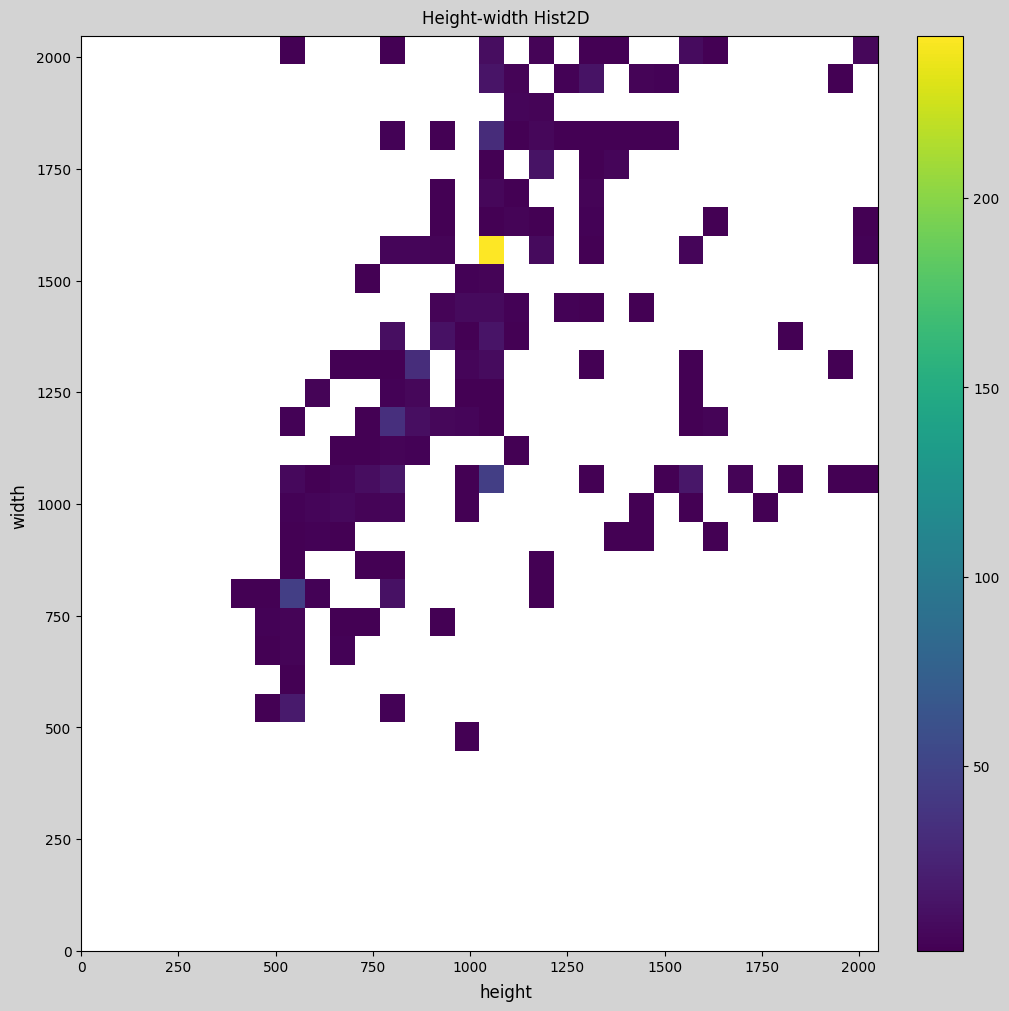

In [125]:
draw_heatmap(df["width"], df["height"])


x.min()=120 y.min()=120 x.max()=6144 y.max()=6144
X_outbound=[2624, 3072, 1856, 2097, 1856, 2048, 2816, 6144, 2048, 2880, 2560, 4288, 1920, 2048, 1680, 2048, 2048, 2048, 2048, 3072, 1472, 2304, 2048, 2048, 2048, 2048, 1331, 3072, 4160, 2048, 2144, 2048, 2048, 2880]
Y_outbound=[3456, 4800, 3456, 2208, 2496, 3328, 4224, 6144, 3072, 3840, 3840, 5376, 2880, 3328, 2096, 3072, 3616, 3584, 3072, 3072, 2224, 3584, 3072, 4096, 3072, 3072, 2496, 3072, 5568, 3680, 2688, 3072, 3328, 3840]


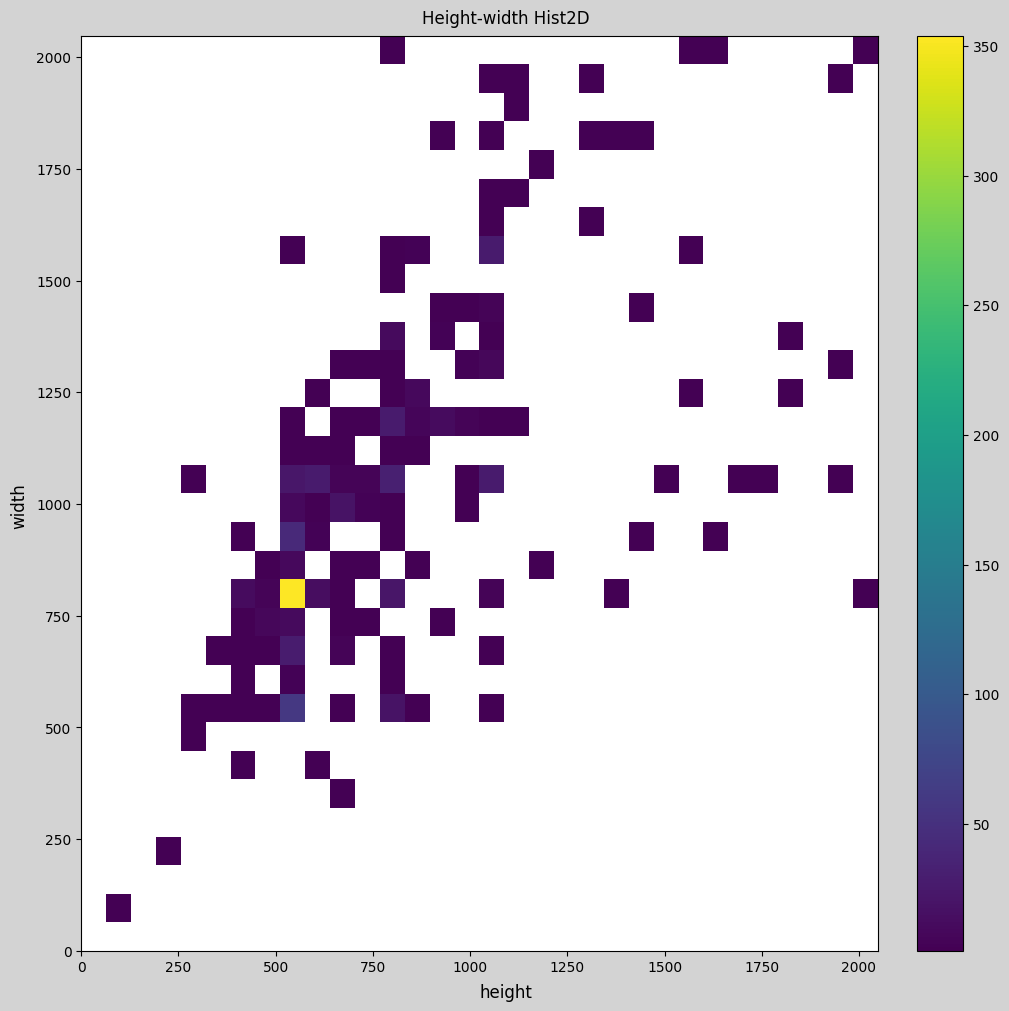

In [126]:
meta_shape = df["meta.Size"][~df["meta.Size"].isna()]
# meta_shape.str.split('x').str[0].astype(int).hist(bins=100)
# draw_heatmap(meta_shape.str.split('x').str[0].astype(int), meta_shape.str.split('x').str[1].astype(int))
meta_x = meta_shape.str.split("x").str[0].astype(int)
meta_y = meta_shape.str.split("x").str[1].astype(int)
draw_heatmap(meta_x, meta_y)


In [127]:
def analyze_prompt(prompt):
    prompt = prompt.dropna()
    length = prompt.apply(lambda x: len(x.split()) if x is not None else 0)
    print(length.describe())


analyze_prompt(df["meta.prompt"])
analyze_prompt(df["meta.negativePrompt"])


count    981.000000
mean      39.124363
std       43.285276
min        1.000000
25%       17.000000
50%       29.000000
75%       49.000000
max      800.000000
Name: meta.prompt, dtype: float64
count    943.000000
mean      35.352068
std       49.476486
min        0.000000
25%        7.000000
50%       17.000000
75%       41.500000
max      576.000000
Name: meta.negativePrompt, dtype: float64
